In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1. Load your clean dataset from Task 1
df_task2 = pd.read_csv('processed_titanic_dataset.csv')

# 2. Create 'FamilySize' (SibSp + Parch + 1 for the passenger themselves)
df_task2['FamilySize'] = df_task2['SibSp'] + df_task2['Parch'] + 1

# 3. Create 'Age_Class_Interaction' (Age multiplied by Pclass)
df_task2['Age_Class_Interaction'] = df_task2['Age'] * df_task2['Pclass']

print("--- Feature Engineering Complete ---")
print(df_task2[['SibSp', 'Parch', 'FamilySize', 'Age', 'Pclass', 'Age_Class_Interaction']].head())

--- Feature Engineering Complete ---
   SibSp  Parch  FamilySize       Age  Pclass  Age_Class_Interaction
0      1      0           2 -0.565736       3              -1.697209
1      0      0           1 -0.258337       3              -0.775011
2      1      0           2  0.433312       1               0.433312
3      0      0           1  0.433312       3               1.299935
4      0      0           1 -0.104637       3              -0.313912


In [8]:
# 1. Isolate target from prediction features
# We drop Survived (target) and ID/Text helper columns
X2 = df_task2.drop(columns=['Survived', 'PassengerId', 'Name', 'Ticket', 'Cabin'])
y2 = df_task2['Survived']

# 2. Split data into 80% Train and 20% Test
X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.20, random_state=42)

print("Data successfully split for Task 2 models!")
print(f"Features used for training: {list(X2.columns)}")

Data successfully split for Task 2 models!
Features used for training: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'FamilySize', 'Age_Class_Interaction']


In [9]:
# 1. Initialize the models with corrected parameter names
log_reg = LogisticRegression(max_iter=1000, random_state=42)
dec_tree = DecisionTreeClassifier(random_state=42, max_depth=5) # Changed max_state to random_state
rand_forest = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Train the models using the engineered training datasets
log_reg.fit(X_train2, y_train2)
dec_tree.fit(X_train2, y_train2)
rand_forest.fit(X_train2, y_train2)

# 3. Make predictions on unseen test feature configurations
pred_log = log_reg.predict(X_test2)
pred_tree = dec_tree.predict(X_test2)
pred_forest = rand_forest.predict(X_test2)

# 4. Calculate overall classification accuracies
acc_log = accuracy_score(y_test2, pred_log)
acc_tree = accuracy_score(y_test2, pred_tree)
acc_forest = accuracy_score(y_test2, pred_forest)

# 5. Display the comparative metrics summary table
print("=============================================")
print("       MODEL ACCURACY COMPARISON RESULTS     ")
print("=============================================")
print(f"1. Logistic Regression Accuracy : {acc_log * 100:.2f}%")
print(f"2. Decision Tree Accuracy       : {acc_tree * 100:.2f}%")
print(f"3. Random Forest Accuracy       : {acc_forest * 100:.2f}%")
print("=============================================")

       MODEL ACCURACY COMPARISON RESULTS     
1. Logistic Regression Accuracy : 81.38%
2. Decision Tree Accuracy       : 80.69%
3. Random Forest Accuracy       : 77.24%


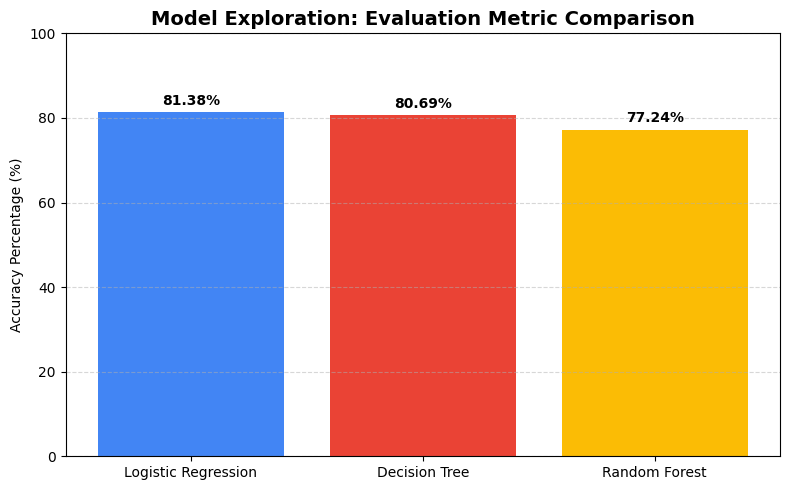

Comparison plot exported as 'model_comparison_chart.png'!


In [10]:
# Create a bar chart comparing accuracy metrics
models = ['Logistic Regression', 'Decision Tree', 'Random Forest']
accuracies = [acc_log * 100, acc_tree * 100, acc_forest * 100]

plt.figure(figsize=(8, 5))
bars = plt.bar(models, accuracies, color=['#4285F4', '#EA4335', '#FBBC05'])

# Annotate values on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 1, f"{yval:.2f}%", ha='center', va='bottom', fontweight='bold')

plt.title('Model Exploration: Evaluation Metric Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy Percentage (%)')
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('model_comparison_chart.png')
plt.show()

print("Comparison plot exported as 'model_comparison_chart.png'!")